# Model Inference Evaluation: Metric Design, A/A Focus, and Cross-Dataset Comparison

This notebook reorganizes the trained-model inference analysis around the questions that the metrics answer.

The first detailed experiment is **A/A**: the model trained on Dataset A is evaluated on Dataset A. This is the realistic prior-free setting. If we do not know the Dynkin classification in advance, we should not choose a test distribution that already encodes the expected answer; Dataset A is the dense, less structured regime that best represents that uncertainty.

The notebook then broadens the analysis to A/A, B/B, A/B, and B/A. Here the first letter denotes the training dataset and the second letter denotes the evaluation dataset. No gallery of every output is shown: structural visualizations are restricted to connected successful outputs and canonical classes up to vertex permutation.

## 1. Load Checkpoints and Evaluation Config

The benchmark keeps the rollout protocol explicit. The full run uses 100 episodes for every model, evaluation dataset, active size `N`, and decoding mode. A pilot can be enabled while checking the notebook. Stochastic decoding samples actions as in PPO and measures the policy's distribution of solutions; greedy decoding takes the highest-probability action at every step and is a deterministic efficiency baseline.

In [10]:
from __future__ import annotations

import math
import os
import random
import sys
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if not (project_root / "src").exists():
    raise FileNotFoundError("Could not locate the project root containing src/.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.analyze import classify_spherical_diagram, load_checkpoint, rollout_episode
from src.coxeter import canonical_code_and_automorphisms, connected_components, num_edges, orbit_size, spherical_margin_and_test
from src.env import DynkinEnv, N_MAX

CHECKPOINTS = {
    "A": project_root / "results" / "A_seed0" / "checkpoint_latest.pt",
    "B": project_root / "results" / "B_seed0" / "checkpoint_latest.pt",
}
RESULTS_DIR = project_root / "results" / "inference_evaluation_comparison"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATASETS = ("A", "B")
MODES = ("stochastic", "greedy")
N_VALUES = tuple(range(1, N_MAX + 1))
EPISODES_PER_COMBINATION = 100
PILOT_EPISODES = 2
RUN_FULL_EVALUATION = True
MAX_EPISODE_STEPS = 30
BASE_SEED = 20260924
DEVICE = "cpu"

np.random.seed(BASE_SEED)
random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)
print(f"Project root: {project_root}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Evaluation sizes: {N_VALUES}")

Project root: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds
Results directory: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\results\inference_evaluation_comparison
Evaluation sizes: (1, 2, 3, 4, 5, 6, 7, 8)


## 2. Define Core Metrics and Dataset Matrix

The primary metric is the success rate by `N`: the fraction of episodes that finish in a spherical diagram. Step counts are conditional on success, so they answer a different question: how efficiently does a policy solve episodes that it can solve? The final spherical margin measures numerical distance from the boundary of the spherical region.

For structural diversity, we retain only successful connected outputs and canonicalize each diagram under vertex permutations. The number of distinct canonical codes therefore counts structural classes rather than labelings of the same graph. The benchmark matrix is model x evaluation dataset x `N` x decoding mode, which yields the four conditions A/A, B/B, A/B, and B/A.

In [11]:
def wilson_interval(successes: int, trials: int, z: float = 1.96) -> tuple[float, float]:
    if trials == 0:
        return float("nan"), float("nan")
    proportion = successes / trials
    denominator = 1.0 + z**2 / trials
    centre = (proportion + z**2 / (2.0 * trials)) / denominator
    radius = z * math.sqrt(proportion * (1.0 - proportion) / trials + z**2 / (4.0 * trials**2)) / denominator
    return max(0.0, centre - radius), min(1.0, centre + radius)


def deterministic_seed(*parts: object) -> int:
    seed = BASE_SEED
    for part in parts:
        seed = (seed * 1_000_003 + sum(ord(char) for char in str(part))) % (2**32 - 1)
    return seed


def checkpoint_metadata(path: Path) -> dict:
    checkpoint = torch.load(path, map_location=DEVICE)
    config = checkpoint["config"]
    return {
        "checkpoint": str(path.relative_to(project_root)),
        "total_steps": int(checkpoint.get("total_steps", -1)),
        "n_max": int(config["n_max"]),
        "hidden_dim": int(config["hidden_dim"]),
        "label_embed_dim": int(config["label_embed_dim"]),
        "n_layers": int(config["n_layers"]),
    }

checkpoint_table = pd.DataFrame([
    {"model": model_name, **checkpoint_metadata(path)}
    for model_name, path in CHECKPOINTS.items()
])
checkpoint_table

,model,checkpoint,total_steps,n_max,hidden_dim,label_embed_dim,n_layers
0,A,results\A_seed0\checkpoint_latest.pt,1999872,8,64,8,3
1,B,results\B_seed0\checkpoint_latest.pt,1999872,8,64,8,3


In [12]:
def collect_episode(model, evaluation_dataset: str, n_active: int, mode: str, seed: int) -> dict:
    if n_active == 1:
        final_diagram = np.zeros((1, 1), dtype=np.int64)
        trajectory = {"states": [final_diagram.copy()], "margins": [], "actions": [], "success": True, "n_steps": 0}
    else:
        environment = DynkinEnv(
            n_max=N_MAX,
            active_ns=(n_active,),
            max_steps=MAX_EPISODE_STEPS,
            dataset=evaluation_dataset,
            seed=seed,
        )
        trajectory = rollout_episode(model, environment, deterministic=(mode == "greedy"))
        final_diagram = trajectory["states"][-1][:n_active, :n_active].copy()

    final_margin, final_spherical = spherical_margin_and_test(final_diagram)
    connected = connected_components(final_diagram) == 1
    row = {
        "evaluation_dataset": evaluation_dataset,
        "n_active": n_active,
        "mode": mode,
        "success": bool(trajectory["success"]),
        "n_steps": int(trajectory["n_steps"]),
        "steps_to_success": int(trajectory["n_steps"]) if trajectory["success"] else np.nan,
        "final_margin": final_margin,
        "final_spherical_check": bool(final_spherical),
        "final_connected": connected,
        "final_edges": num_edges(final_diagram),
        "canonical_code": np.nan,
        "automorphism_count": np.nan,
        "orbit_size": np.nan,
        "coxeter_type": None,
        "final_diagram": final_diagram,
        "states": trajectory["states"],
        "margins": trajectory["margins"],
        "actions": trajectory["actions"],
    }
    if row["success"]:
        assert final_spherical, "The trajectory reported success but the spherical test failed."
        code, automorphism_count = canonical_code_and_automorphisms(final_diagram)
        row["canonical_code"] = int(code)
        row["automorphism_count"] = int(automorphism_count)
        row["orbit_size"] = int(orbit_size(final_diagram))
        row["coxeter_type"] = classify_spherical_diagram(final_diagram, n_active=n_active)
    return row


def run_evaluation(episodes_per_combination: int) -> pd.DataFrame:
    rows = []
    for model_name, checkpoint_path in CHECKPOINTS.items():
        if not checkpoint_path.exists():
            raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
        model, _config = load_checkpoint(checkpoint_path, device=DEVICE)
        for evaluation_dataset in DATASETS:
            for n_active in N_VALUES:
                for mode in MODES:
                    seed = deterministic_seed(model_name, evaluation_dataset, n_active, mode)
                    for episode_index in range(episodes_per_combination):
                        episode = collect_episode(model, evaluation_dataset, n_active, mode, seed + episode_index)
                        rows.append({
                            "model": model_name,
                            "condition": f"{model_name}/{evaluation_dataset}",
                            "episode": episode_index,
                            **{key: value for key, value in episode.items() if key not in {"final_diagram", "states", "margins", "actions"}},
                            "final_diagram": episode["final_diagram"],
                        })
        del model
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    return pd.DataFrame(rows)


def normalize_type(value: object) -> str | None:
    if value is None:
        return None
    if isinstance(value, (list, tuple)):
        return " x ".join(map(str, value))
    return str(value)


def summarize_episodes(episodes_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_columns = ["model", "evaluation_dataset", "n_active", "mode"]
    for group_values, group in episodes_frame.groupby(group_columns, sort=True):
        model, evaluation_dataset, n_active, mode = group_values
        successes = int(group["success"].sum())
        ci_low, ci_high = wilson_interval(successes, len(group))
        successful_steps = group.loc[group["success"], "steps_to_success"]
        connected = group.loc[group["success"] & group["final_connected"]]
        rows.append({
            "model": model,
            "evaluation_dataset": evaluation_dataset,
            "condition": f"{model}/{evaluation_dataset}",
            "n_active": n_active,
            "mode": mode,
            "episodes": len(group),
            "successes": successes,
            "success_rate": successes / len(group),
            "success_ci_low": ci_low,
            "success_ci_high": ci_high,
            "mean_steps_success": successful_steps.mean() if len(successful_steps) else np.nan,
            "median_steps_success": successful_steps.median() if len(successful_steps) else np.nan,
            "connected_success_rate": len(connected) / len(group),
            "unique_connected_classes": int(connected["canonical_code"].dropna().nunique()),
            "mean_final_margin": group["final_margin"].mean(),
        })
    return pd.DataFrame(rows)

## 3. Run Stochastic vs Greedy Rollouts

Each rollout records the complete trajectory, final diagram, action count, success flag, spherical margin, connectivity, and canonical output code. Stochastic episodes preserve the exploration behavior of the learned PPO policy. Greedy episodes remove sampling noise and expose the policy's preferred path, making them useful for efficiency and reproducibility but not a replacement for the stochastic evaluation.

In [13]:
episodes_per_combination = EPISODES_PER_COMBINATION if RUN_FULL_EVALUATION else PILOT_EPISODES
episodes = run_evaluation(episodes_per_combination)
episodes["coxeter_type"] = episodes["coxeter_type"].map(normalize_type)
summary = summarize_episodes(episodes)
print(f"Collected {len(episodes):,} episodes across {len(summary):,} condition-size-mode groups.")
summary.head()

Collected 6,400 episodes across 64 condition-size-mode groups.


,model,evaluation_dataset,condition,n_active,mode,episodes,successes,success_rate,success_ci_low,success_ci_high,mean_steps_success,median_steps_success,connected_success_rate,unique_connected_classes,mean_final_margin
0,A,A,A/A,1,greedy,100,100,1.0,0.963005,1.0,0.00,0.0,1.00,1,2.00000
1,A,A,A/A,1,stochastic,100,100,1.0,0.963005,1.0,0.00,0.0,1.00,1,2.00000
2,A,A,A/A,2,greedy,100,100,1.0,0.963005,1.0,1.00,1.0,0.00,0,2.00000
3,A,A,A/A,2,stochastic,100,100,1.0,0.963005,1.0,1.00,1.0,0.00,0,2.00000
4,A,A,A/A,3,greedy,100,100,1.0,0.963005,1.0,1.21,1.0,0.24,2,0.83001


## 4. Success Rate and Step Efficiency by N

Success is plotted with 95% Wilson intervals because each point is a binomial proportion. Step efficiency is shown only among successful episodes: a lower median means a shorter successful trajectory, but it must never be interpreted without the corresponding success rate. Both plots retain the stochastic/greedy distinction so that exploration and deterministic preference remain visible.

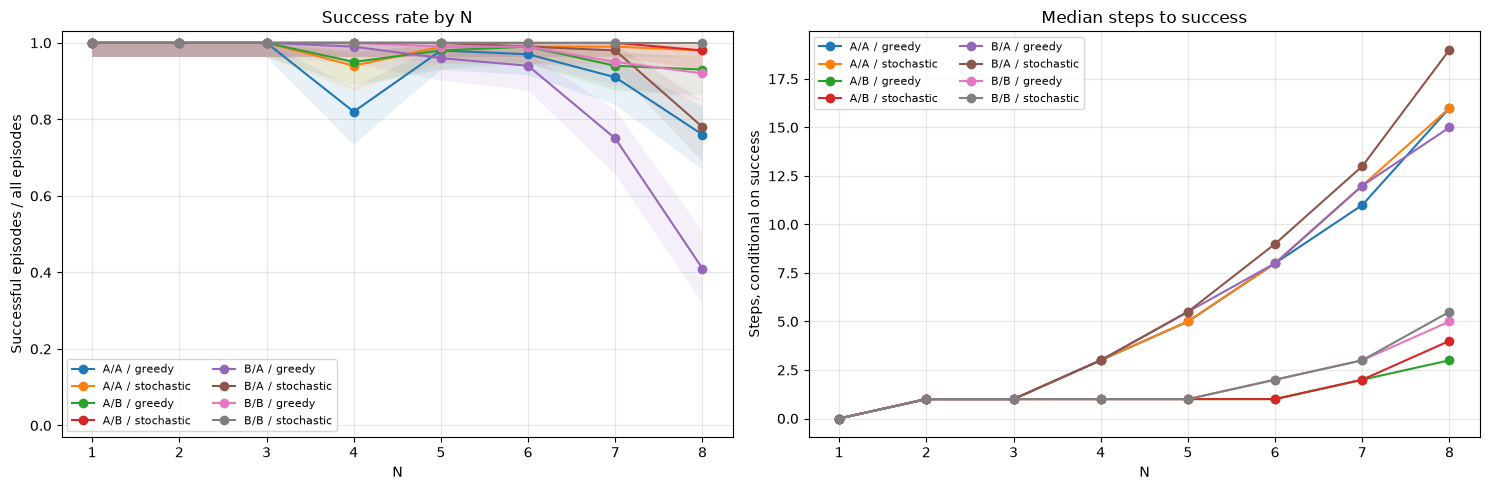

In [14]:
def plot_success_and_steps(summary_frame: pd.DataFrame, conditions: tuple[str, ...] | None = None, title_prefix: str = "") -> None:
    frame = summary_frame if conditions is None else summary_frame[summary_frame["condition"].isin(conditions)]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for (condition, mode), group in frame.groupby(["condition", "mode"], sort=True):
        group = group.sort_values("n_active")
        label = f"{condition} / {mode}"
        axes[0].plot(group["n_active"], group["success_rate"], "o-", label=label)
        axes[0].fill_between(group["n_active"], group["success_ci_low"], group["success_ci_high"], alpha=0.10)
        axes[1].plot(group["n_active"], group["median_steps_success"], "o-", label=label)
    axes[0].set_title(f"{title_prefix}Success rate by N")
    axes[0].set_ylabel("Successful episodes / all episodes")
    axes[0].set_ylim(-0.03, 1.03)
    axes[1].set_title(f"{title_prefix}Median steps to success")
    axes[1].set_ylabel("Steps, conditional on success")
    for axis in axes:
        axis.set_xlabel("N")
        axis.set_xticks(N_VALUES)
        axis.grid(alpha=0.3)
        axis.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()

plot_success_and_steps(summary)

## 5. Diversity, Canonical Classes, and Permutation-Invariant Statistics

Diversity is computed from connected successful outputs only. Canonical coding quotients out vertex relabeling, while the orbit size and automorphism count provide additional information about symmetry. Coxeter-type frequencies describe which structural families appear, but they are interpreted as a secondary descriptive statistic rather than as the definition of success.

In [15]:
def connected_successes(episodes_frame: pd.DataFrame) -> pd.DataFrame:
    return episodes_frame[
        episodes_frame["success"]
        & episodes_frame["final_connected"]
        & episodes_frame["canonical_code"].notna()
    ].copy()


def diversity_table(episodes_frame: pd.DataFrame) -> pd.DataFrame:
    connected = connected_successes(episodes_frame)
    return (
        connected.groupby(["condition", "model", "evaluation_dataset", "n_active", "mode"], sort=True)
        .agg(
            connected_successes=("canonical_code", "size"),
            unique_canonical_classes=("canonical_code", "nunique"),
            mean_orbit_size=("orbit_size", "mean"),
            mean_automorphism_count=("automorphism_count", "mean"),
        )
        .reset_index()
    )


def plot_diversity(episodes_frame: pd.DataFrame, conditions: tuple[str, ...] | None = None, title_prefix: str = "") -> None:
    frame = episodes_frame if conditions is None else episodes_frame[episodes_frame["condition"].isin(conditions)]
    diversity = diversity_table(frame)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for (condition, mode), group in diversity.groupby(["condition", "mode"], sort=True):
        group = group.sort_values("n_active")
        label = f"{condition} / {mode}"
        axes[0].plot(group["n_active"], group["unique_canonical_classes"], "o-", label=label)
        axes[1].plot(group["n_active"], group["mean_orbit_size"], "o-", label=label)
    axes[0].set_title(f"{title_prefix}Distinct connected canonical classes")
    axes[0].set_ylabel("Unique classes, up to vertex permutation")
    axes[1].set_title(f"{title_prefix}Mean permutation orbit size")
    axes[1].set_ylabel("Mean orbit size")
    for axis in axes:
        axis.set_xlabel("N")
        axis.set_xticks(N_VALUES)
        axis.grid(alpha=0.3)
        axis.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()


def coxeter_type_table(episodes_frame: pd.DataFrame) -> pd.DataFrame:
    connected = connected_successes(episodes_frame)
    return (
        connected.groupby(["condition", "mode", "n_active", "coxeter_type"], dropna=False)
        .size()
        .reset_index(name="episodes")
    )

print("Canonical diversity summary:")
diversity_table(episodes).head(12)
print("Coxeter-type frequencies:")
coxeter_type_table(episodes).head(12)

Canonical diversity summary:
Coxeter-type frequencies:


,condition,mode,n_active,coxeter_type,episodes
0,A/A,greedy,1,A_1,100
1,A/A,greedy,3,A_3,11
2,A/A,greedy,3,B_3/C_3,13
3,A/A,greedy,4,A_4,2
4,A/A,greedy,4,B_4/C_4,5
5,A/A,greedy,4,D_4,1
6,A/A,greedy,5,A_5,7
7,A/A,greedy,5,B_5/C_5,7
8,A/A,greedy,5,D_5,3
9,A/A,greedy,6,A_6,8


## 6. Focused A/A Analysis: Realistic Prior-Free Evaluation

A/A is the first substantive reading of the results. It asks whether the model trained on the dense, less structured Dataset A can solve fresh Dataset A instances without relying on prior knowledge of the Dynkin classification. This is the most relevant operational test when the classification is unknown beforehand.

The stochastic curves are the primary result because they reflect the policy as used during PPO. Greedy curves are shown alongside them as a deterministic diagnostic: they can reveal a clean preferred trajectory, but a strong greedy score alone does not establish that the policy explores a rich solution distribution.

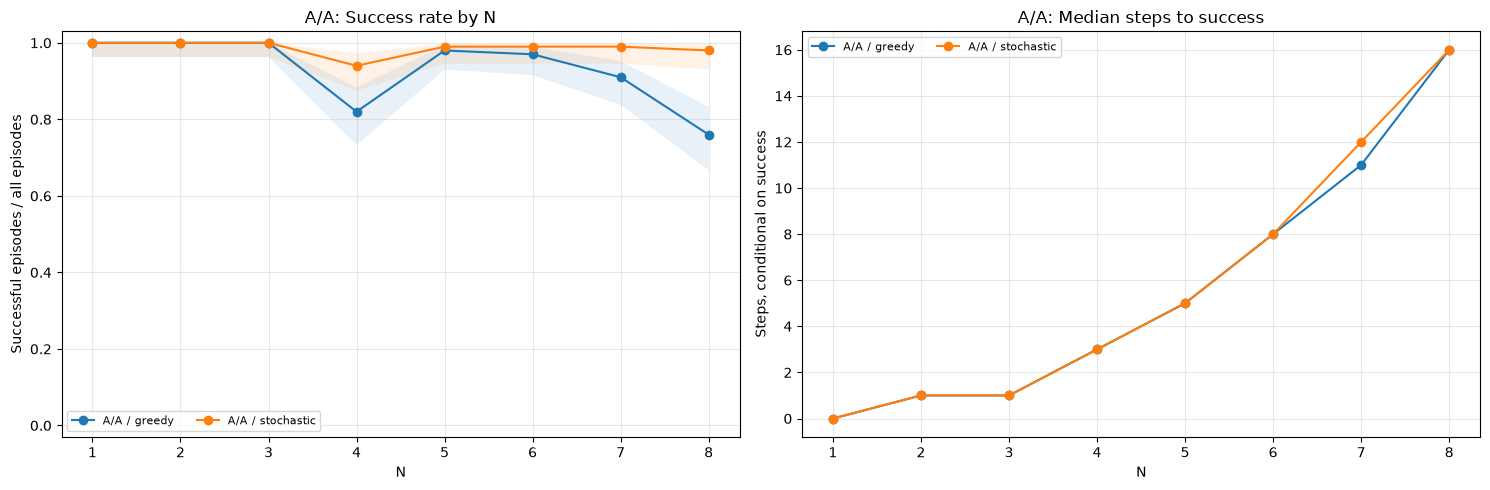

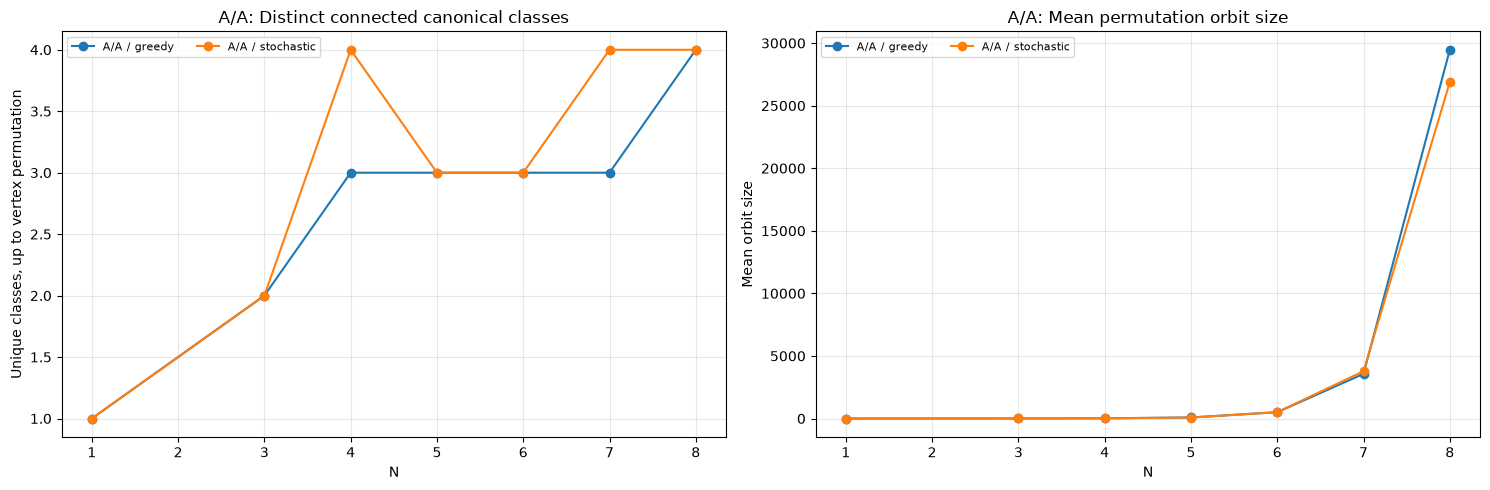

,condition,n_active,mode,success_rate,median_steps_success,connected_success_rate,unique_connected_classes,mean_final_margin
0,A/A,1,greedy,1.00,0.0,1.00,1,2.000000
2,A/A,2,greedy,1.00,1.0,0.00,0,2.000000
4,A/A,3,greedy,1.00,1.0,0.24,2,0.830010
6,A/A,4,greedy,0.82,3.0,0.08,3,0.514940
8,A/A,5,greedy,0.98,5.0,0.17,3,0.505438
10,A/A,6,greedy,0.97,8.0,0.15,3,0.379940
12,A/A,7,greedy,0.91,11.0,0.12,3,0.213492
14,A/A,8,greedy,0.76,16.0,0.13,4,-0.105880
1,A/A,1,stochastic,1.00,0.0,1.00,1,2.000000
3,A/A,2,stochastic,1.00,1.0,0.00,0,2.000000


In [16]:
AA_CONDITION = ("A/A",)
plot_success_and_steps(summary, conditions=AA_CONDITION, title_prefix="A/A: ")
plot_diversity(episodes, conditions=AA_CONDITION, title_prefix="A/A: ")

aa_summary = summary[summary["condition"] == "A/A"].sort_values(["mode", "n_active"])
aa_summary[[
    "condition", "n_active", "mode", "success_rate", "median_steps_success",
    "connected_success_rate", "unique_connected_classes", "mean_final_margin",
]]

## 7. Connected Successful Outputs for A/A

The following visualization is deliberately compact. It selects at most two distinct canonical classes per model, size, and decoding mode, and it never shows disconnected or unsuccessful outputs. Thus the figure illustrates structural representatives after quotienting out vertex labels rather than displaying every graph produced by the benchmark.

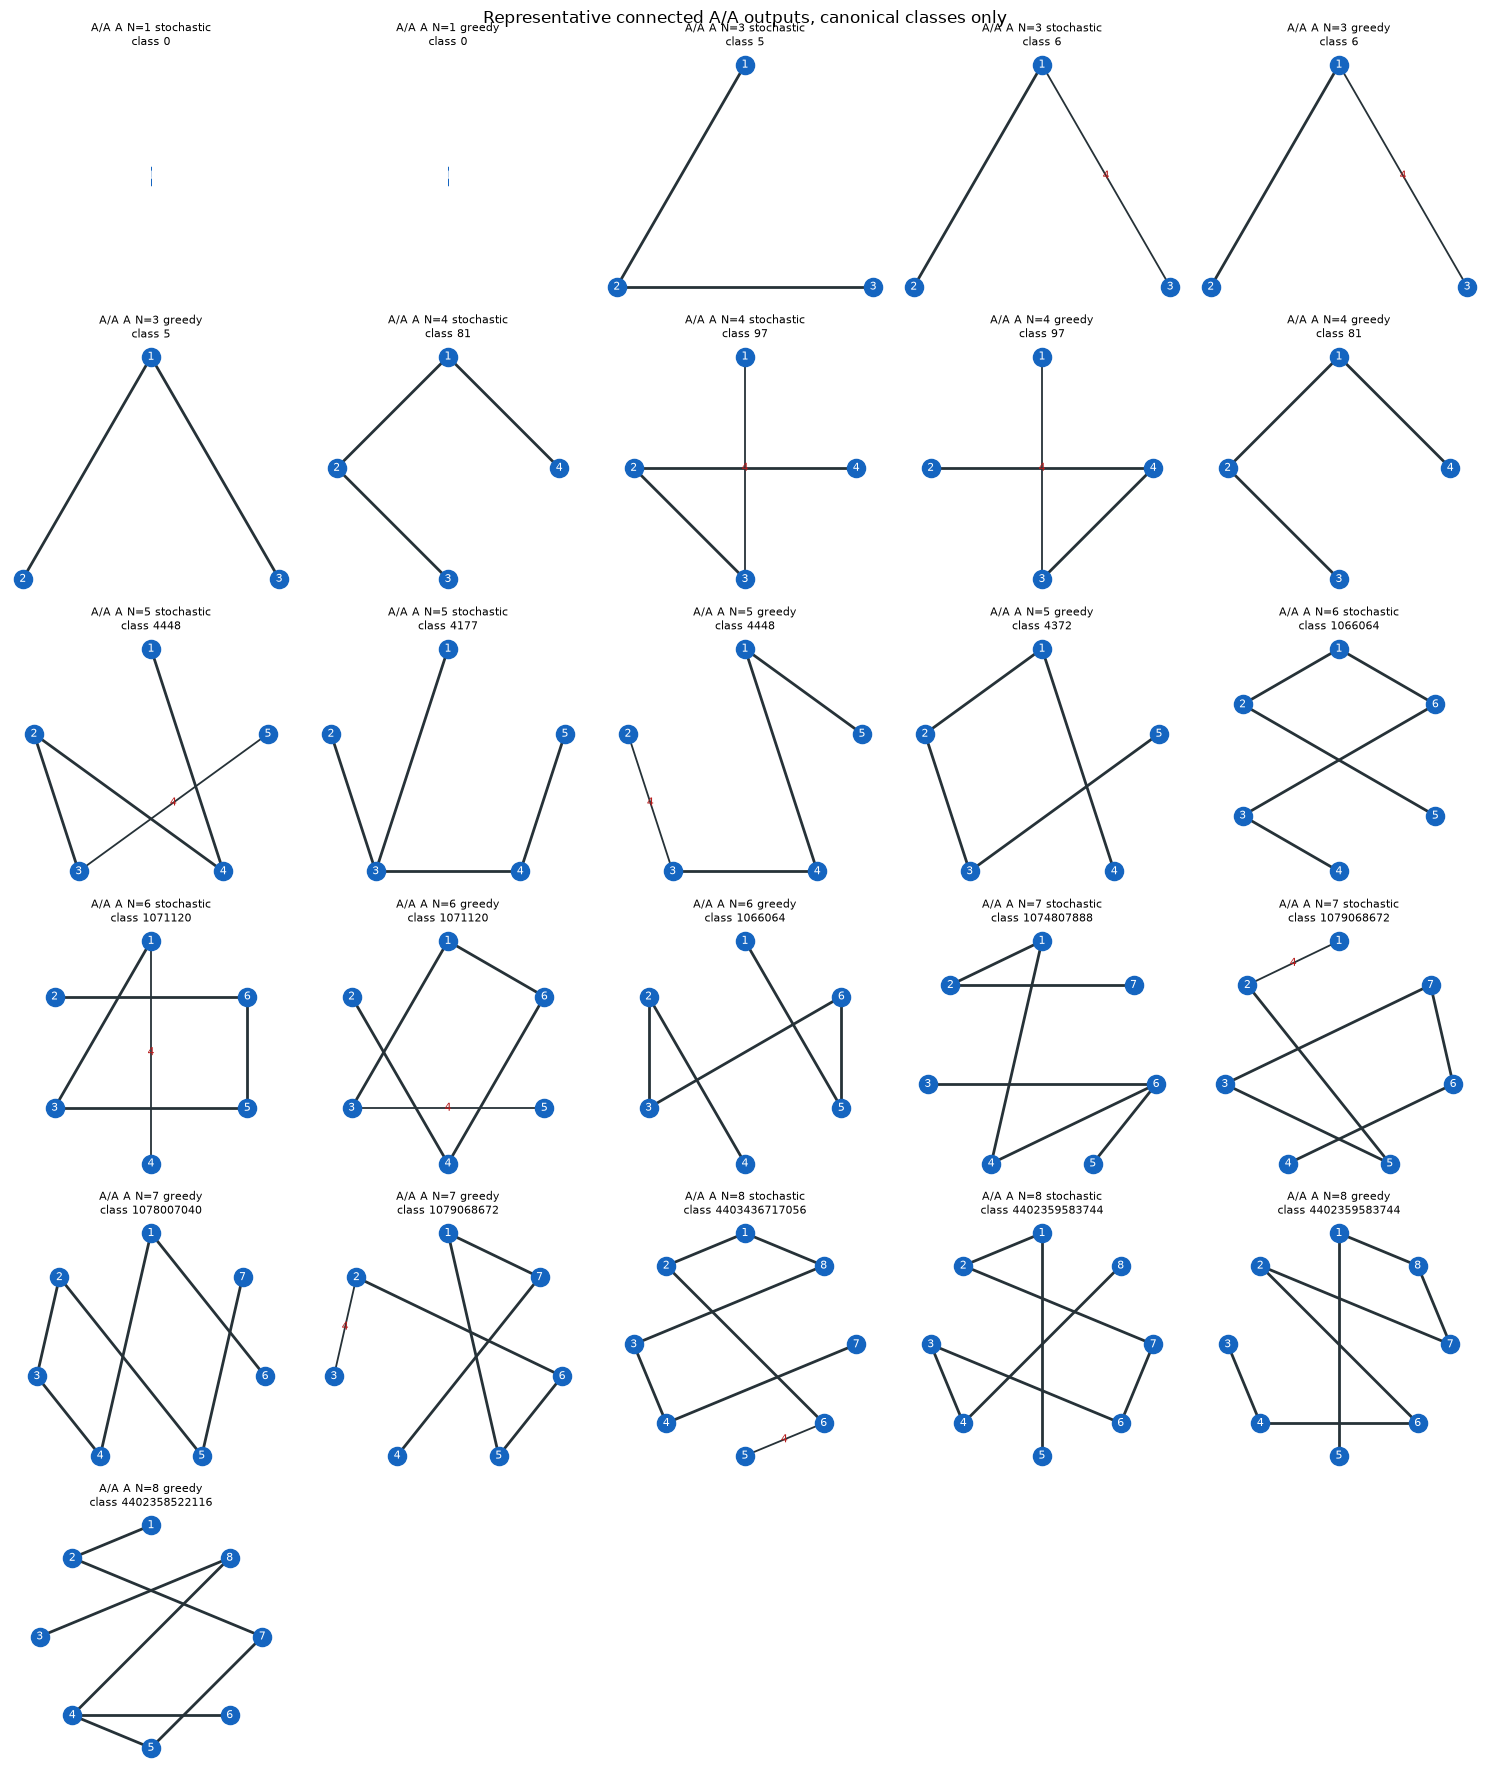

In [17]:
from src.coxeter import edge_list


def draw_diagram(axis, matrix: np.ndarray, title: str) -> None:
    n = matrix.shape[0]
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False) + np.pi / 2
    positions = np.column_stack([np.cos(angles), np.sin(angles)])
    for i, j in edge_list(matrix):
        label = int(matrix[i, j])
        axis.plot(
            [positions[i, 0], positions[j, 0]],
            [positions[i, 1], positions[j, 1]],
            color="#263238",
            linewidth=2.0 if label == 3 else 1.3,
            linestyle="-" if label in (3, 4) else "--",
            zorder=1,
        )
        if label != 3:
            midpoint = (positions[i] + positions[j]) / 2
            axis.text(midpoint[0], midpoint[1], str(label), fontsize=8, ha="center", va="center", color="#b71c1c")
    axis.scatter(positions[:, 0], positions[:, 1], s=170, color="#1565c0", zorder=2)
    for index, (x_coord, y_coord) in enumerate(positions):
        axis.text(x_coord, y_coord, str(index + 1), color="white", ha="center", va="center", fontsize=8, zorder=3)
    axis.set_title(title, fontsize=8)
    axis.set_aspect("equal")
    axis.axis("off")


def plot_aa_representatives(episodes_frame: pd.DataFrame, per_group: int = 2) -> None:
    candidates = connected_successes(episodes_frame)
    candidates = candidates[candidates["condition"] == "A/A"]
    candidates = candidates.drop_duplicates(["model", "n_active", "mode", "canonical_code"])
    candidates = candidates.groupby(["model", "n_active", "mode"], group_keys=False).head(per_group)
    if candidates.empty:
        print("No connected A/A successes are available for visualization.")
        return
    columns = min(5, len(candidates))
    rows = math.ceil(len(candidates) / columns)
    figure, axes = plt.subplots(rows, columns, figsize=(3.0 * columns, 3.0 * rows), squeeze=False)
    for axis, (_, row) in zip(axes.flat, candidates.iterrows()):
        title = f"A/A {row['model']} N={row['n_active']} {row['mode']}\nclass {int(row['canonical_code'])}"
        draw_diagram(axis, row["final_diagram"], title)
    for axis in axes.flat[len(candidates):]:
        axis.axis("off")
    figure.suptitle("Representative connected A/A outputs, canonical classes only")
    figure.tight_layout()
    plt.show()

plot_aa_representatives(episodes)

## 8. Comparative Evaluation Across A/A, B/B, A/B, and B/A

The full comparison separates in-distribution behavior from transfer. A/A and B/B are matched training/evaluation distributions. A/B asks whether the A-trained model transfers to the sparse-tree control regime, while B/A asks whether the B-trained model transfers to the dense, less structured regime. The same distinction is shown for stochastic and greedy decoding.

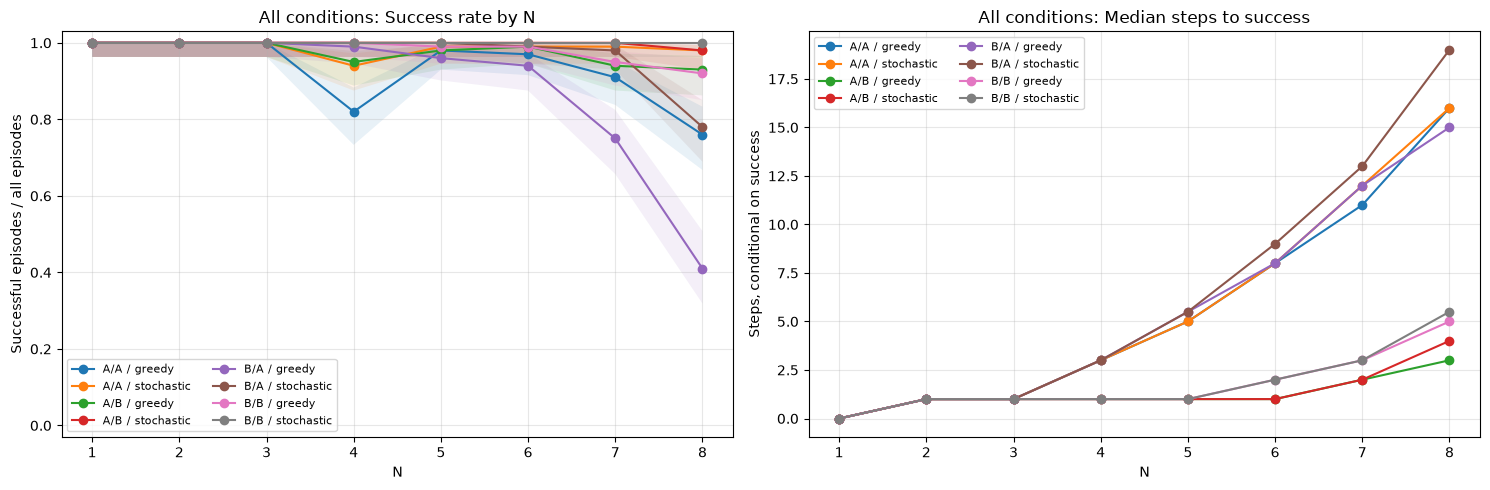

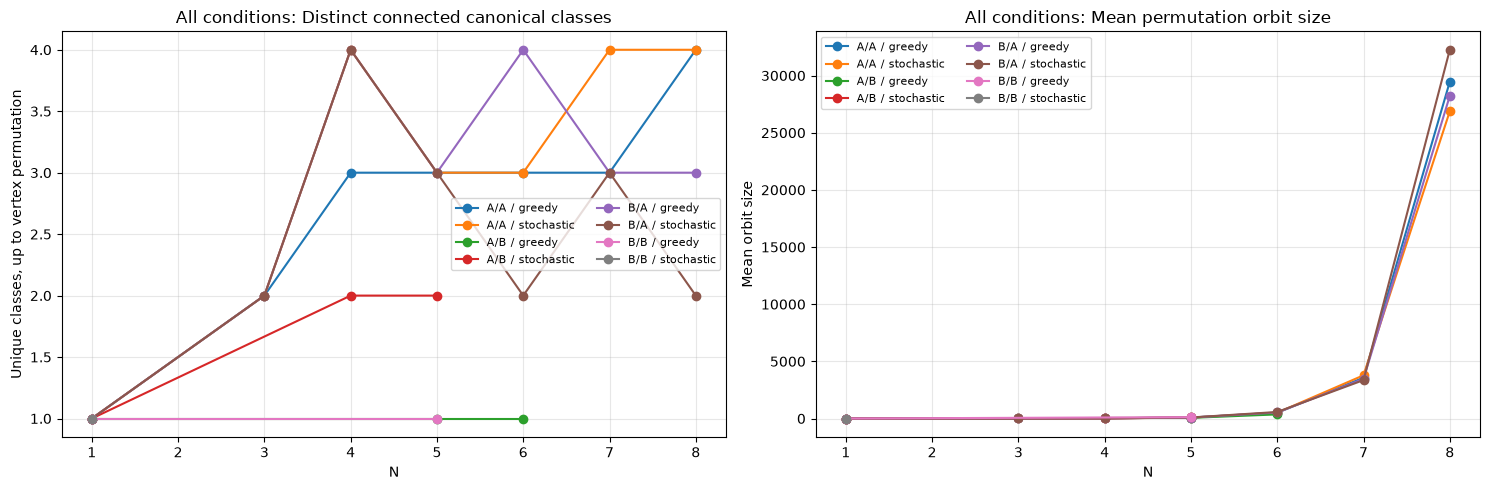

,condition,mode,mean_success_rate,mean_median_steps,mean_connected_success_rate,mean_unique_classes,mean_final_margin
0,A/A,greedy,0.93000,5.6250,0.23625,2.375,0.792242
1,A/A,stochastic,0.98625,5.7500,0.24250,2.625,0.884768
2,A/B,greedy,0.97375,1.2500,0.12750,0.375,1.145738
3,A/B,stochastic,0.99750,1.3750,0.13000,0.625,1.178816
4,B/A,greedy,0.88125,5.6875,0.20750,2.500,0.645329
5,B/A,stochastic,0.96875,6.4375,0.20875,2.125,0.952625
6,B/B,greedy,0.98125,1.7500,0.12625,0.250,1.349313
7,B/B,stochastic,1.00000,1.8125,0.12500,0.125,1.360104


In [18]:
COMPARISON_CONDITIONS = ("A/A", "B/B", "A/B", "B/A")
plot_success_and_steps(summary, conditions=COMPARISON_CONDITIONS, title_prefix="All conditions: ")
plot_diversity(episodes, conditions=COMPARISON_CONDITIONS, title_prefix="All conditions: ")

# A compact condition x mode table makes the in-distribution and transfer contrast easy to scan.
comparison_table = (
    summary.groupby(["condition", "mode"], sort=True)
    .agg(
        mean_success_rate=("success_rate", "mean"),
        mean_median_steps=("median_steps_success", "mean"),
        mean_connected_success_rate=("connected_success_rate", "mean"),
        mean_unique_classes=("unique_connected_classes", "mean"),
        mean_final_margin=("mean_final_margin", "mean"),
    )
    .reset_index()
)
comparison_table

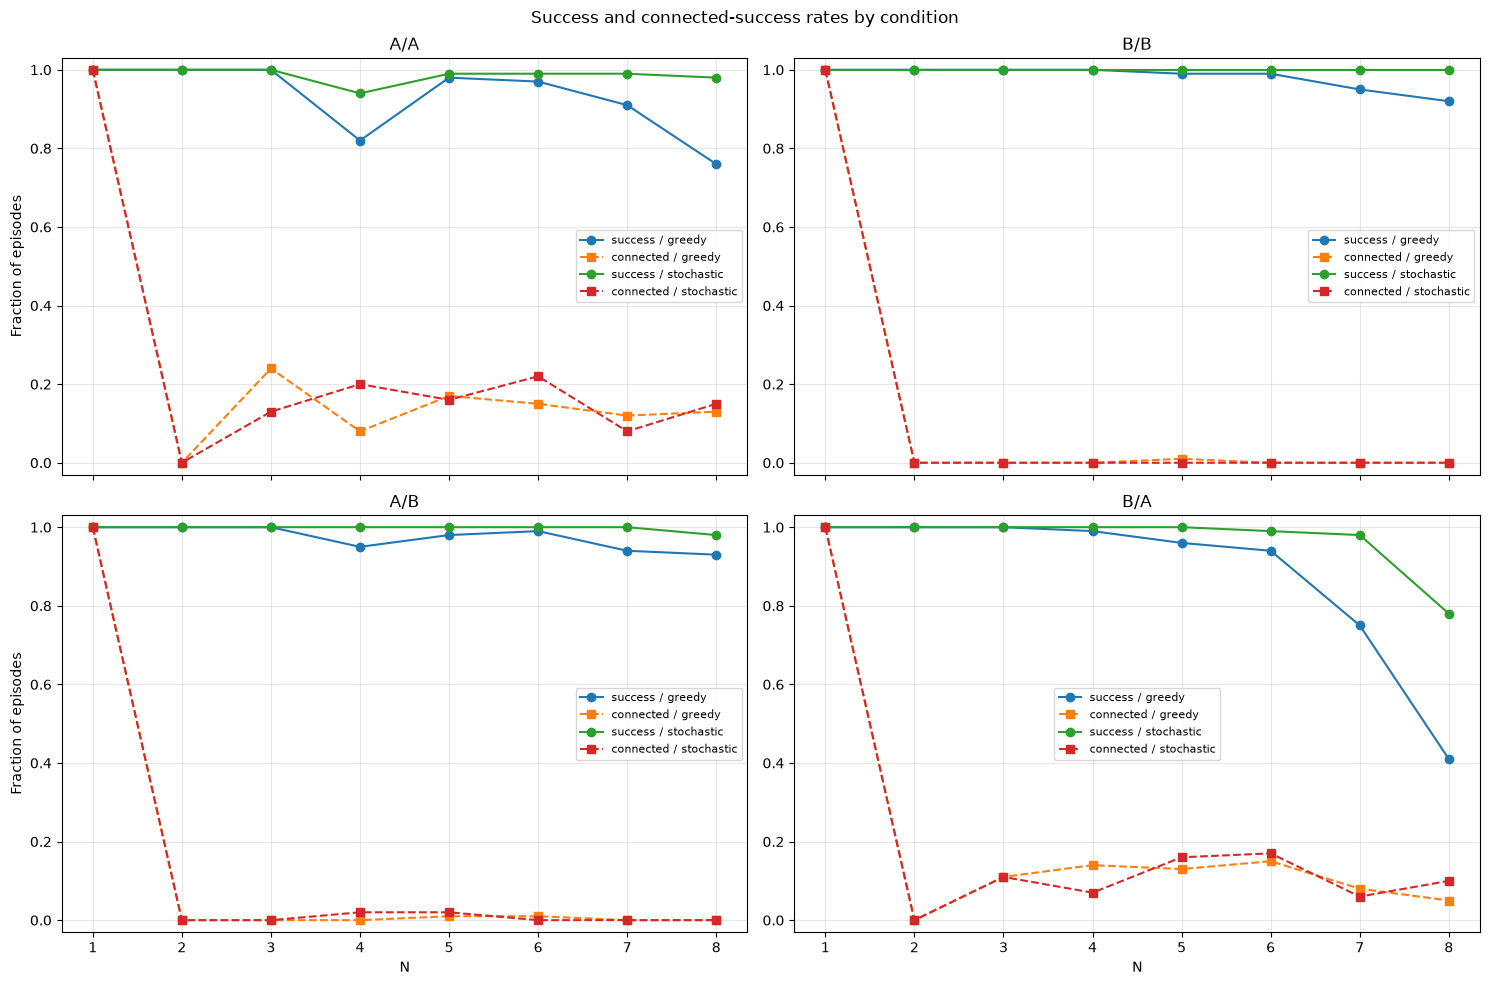

In [19]:
def plot_condition_panels(summary_frame: pd.DataFrame) -> None:
    figure, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
    for axis, condition in zip(axes.flat, COMPARISON_CONDITIONS):
        subset = summary_frame[summary_frame["condition"] == condition]
        for mode, group in subset.groupby("mode", sort=True):
            group = group.sort_values("n_active")
            axis.plot(group["n_active"], group["success_rate"], "o-", label=f"success / {mode}")
            axis.plot(group["n_active"], group["connected_success_rate"], "s--", label=f"connected / {mode}")
        axis.set_title(condition)
        axis.set_ylim(-0.03, 1.03)
        axis.set_xticks(N_VALUES)
        axis.grid(alpha=0.3)
        axis.legend(fontsize=8)
    for axis in axes[-1, :]:
        axis.set_xlabel("N")
    for axis in axes[:, 0]:
        axis.set_ylabel("Fraction of episodes")
    figure.suptitle("Success and connected-success rates by condition")
    figure.tight_layout()
    plt.show()

plot_condition_panels(summary)

## 9. Model Ranking Across Metrics and Interpretation

The final ranking compares models within each evaluation dataset and decoding mode. Success rate and final spherical margin are better when larger; step efficiency is better when smaller; connected diversity and canonical-class richness are better when larger. Because diversity is only defined over connected successes, it is interpreted together with success rather than as a standalone objective.

In [20]:
ranking_metrics = {
    "success rate": ("success_rate", True),
    "step efficiency": ("median_steps_success", False),
    "connected diversity": ("connected_success_rate", True),
    "canonical-class richness": ("unique_connected_classes", True),
    "spherical margin": ("mean_final_margin", True),
}

ranking_rows = []
for evaluation_dataset in DATASETS:
    for mode in MODES:
        subset = summary[summary["evaluation_dataset"] == evaluation_dataset]
        subset = subset[subset["mode"] == mode]
        by_model = subset.groupby("model", sort=True)[list(metric for metric, _ in ranking_metrics.values())].mean()
        for metric_name, (column, higher_is_better) in ranking_metrics.items():
            values = by_model[column].dropna()
            if values.empty:
                winner = "undetermined"
            else:
                best_value = values.max() if higher_is_better else values.min()
                winners = values.index[np.isclose(values.to_numpy(), best_value)].tolist()
                winner = "tie: " + ", ".join(winners) if len(winners) > 1 else winners[0]
            ranking_rows.append({
                "evaluation_dataset": evaluation_dataset,
                "mode": mode,
                "metric": metric_name,
                "winner": winner,
                "A_value": by_model.loc["A", column] if "A" in by_model.index else np.nan,
                "B_value": by_model.loc["B", column] if "B" in by_model.index else np.nan,
            })

ranking_table = pd.DataFrame(ranking_rows)
ranking_table

,evaluation_dataset,mode,metric,winner,A_value,B_value
0,A,stochastic,success rate,A,0.986250,0.968750
1,A,stochastic,step efficiency,A,5.750000,6.437500
2,A,stochastic,connected diversity,A,0.242500,0.208750
3,A,stochastic,canonical-class richness,A,2.625000,2.125000
4,A,stochastic,spherical margin,B,0.884768,0.952625
5,A,greedy,success rate,A,0.930000,0.881250
6,A,greedy,step efficiency,A,5.625000,5.687500
7,A,greedy,connected diversity,A,0.236250,0.207500
8,A,greedy,canonical-class richness,B,2.375000,2.500000
9,A,greedy,spherical margin,A,0.792242,0.645329


In [21]:
for evaluation_dataset in DATASETS:
    for mode in MODES:
        winners = ranking_table[
            (ranking_table["evaluation_dataset"] == evaluation_dataset)
            & (ranking_table["mode"] == mode)
        ]
        statements = "; ".join(
            f"{row.metric}: {row.winner}"
            for row in winners.itertuples()
        )
        print(f"Evaluation dataset {evaluation_dataset}, {mode}: {statements}")

serializable_episodes = episodes.drop(columns=["final_diagram"], errors="ignore").copy()
serializable_episodes.to_csv(RESULTS_DIR / "episode_metrics.csv", index=False)
summary.to_csv(RESULTS_DIR / "aggregate_metrics.csv", index=False)
comparison_table.to_csv(RESULTS_DIR / "comparison_metrics.csv", index=False)
ranking_table.to_csv(RESULTS_DIR / "model_ranking.csv", index=False)
checkpoint_table.to_csv(RESULTS_DIR / "checkpoint_metadata.csv", index=False)
print(f"Saved evaluation tables to {RESULTS_DIR}")

Evaluation dataset A, stochastic: success rate: A; step efficiency: A; connected diversity: A; canonical-class richness: A; spherical margin: B
Evaluation dataset A, greedy: success rate: A; step efficiency: A; connected diversity: A; canonical-class richness: B; spherical margin: A
Evaluation dataset B, stochastic: success rate: B; step efficiency: A; connected diversity: A; canonical-class richness: A; spherical margin: B
Evaluation dataset B, greedy: success rate: B; step efficiency: A; connected diversity: A; canonical-class richness: A; spherical margin: B
Saved evaluation tables to D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\results\inference_evaluation_comparison


### Comparative conclusion

The ranking table and printed statements above are the final model comparison. For each evaluation dataset and decoding mode, they identify which model performed best in success rate, step efficiency, connected diversity, canonical-class richness, and spherical margin.

The main conclusion should be drawn from **A/A under stochastic decoding**: this is the prior-free realistic setting, so its strongest model is the most relevant overall answer. B/B measures control performance on the sparse-tree regime, while A/B and B/A expose transfer asymmetry. A model that wins in-distribution but loses under transfer is specialized; a model that remains competitive in both transfer directions is more robust.

Greedy decoding should be read as a clean efficiency baseline. Stochastic decoding is the policy-level result and can achieve broader canonical diversity through exploration, even when it uses more steps or has a lower point estimate for success. The best model is therefore metric-dependent: success and robustness prioritize reliable completion, efficiency prioritizes shorter successful trajectories, and diversity prioritizes structurally distinct connected classes after quotienting out vertex labels.